## **1. Importing Required Libraries**

In [1]:
import time
import warnings
from itertools import cycle, islice
import matplotlib.pyplot as plt
import numpy as np
from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from skimage.filters import sobel
from skimage import morphology, measure
from scipy.ndimage import binary_fill_holes

## **2. Generating Dataset**

In [2]:
# ============
# Generate datasets
# ============
n_samples = 2000
seed = 30
noisy_circles = datasets.make_circles(
    n_samples=n_samples, factor=0.5, noise=0.05, random_state=seed
)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=seed)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=seed)
rng = np.random.RandomState(seed)
no_structure = rng.rand(n_samples, 2), None

# Anisotropicly distributed data
random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

# Blobs with varied variances
varied = datasets.make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)

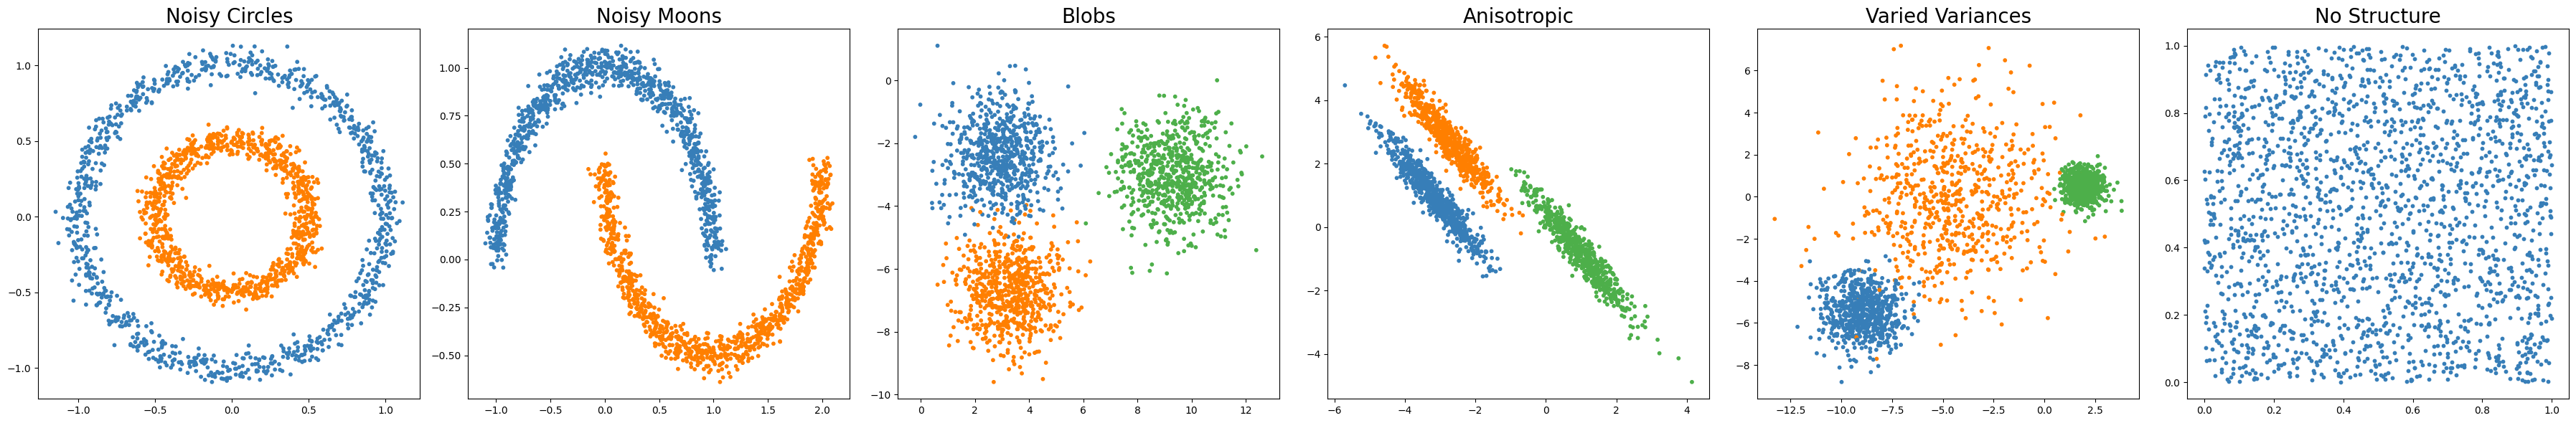

In [3]:
# Define the custom colormap function
def get_custom_colors(num_clusters):
    if num_clusters <= 0:
        raise ValueError("Number of clusters must be greater than 0")
    colors = np.array(
        list(islice(cycle([
            "#377eb8", "#ff7f00", "#4daf4a", "#f781bf",
            "#a65628", "#984ea3", "#999999", "#e41a1c", "#dede00"
        ]), num_clusters))
    )
    return colors

# Create a figure with 1 row and 6 columns
fig, axes = plt.subplots(1, 6, figsize=(36, 6))  # Adjust figsize for clarity

# List of datasets and their labels
datasets = [noisy_circles, noisy_moons, blobs, aniso, varied, no_structure]
titles = ["Noisy Circles", "Noisy Moons", "Blobs", "Anisotropic", "Varied Variances", "No Structure"]

# Loop through datasets and plot each one
for i, (ax, dataset, title) in enumerate(zip(axes, datasets, titles)):
    X, y = dataset[0], dataset[1]  # Extract data points and labels

    # Check if labels are valid
    if y is None:
        ax.scatter(X[:, 0], X[:, 1], s=10, c="#377eb8")  # Default blue color for unlabeled data
    else:
        num_clusters = len(np.unique(y))
        colors = get_custom_colors(num_clusters)  # Apply custom colors
        ax.scatter(X[:, 0], X[:, 1], s=10, c=[colors[label] for label in y])  # Use 'c' instead of 'color'

    ax.set_title(title, fontsize=20)
    # ax.axis('off')  # Optional: Remove axis for a cleaner look

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


## **3. Our Clustering Algorithm**

### **3.1 Function for our Algorithm**

In [7]:
def clustering_with_image_segmentation(points, image_size=(128, 256), radius=3):

    # Step 1: Create an empty image and plot points onto it
    scatter_image = np.zeros(image_size, dtype=np.uint8)

    # Normalize the points to the range [0, image_size[0] - 1] and [0, image_size[1] - 1]
    x_min, x_max = np.min(points[:, 0]), np.max(points[:, 0])
    y_min, y_max = np.min(points[:, 1]), np.max(points[:, 1])

    # Map points to the range [0, 255] for both x and y
    normalized_points = []
    for point in points:
        x, y = point
        normalized_x = int((x - x_min) / (x_max - x_min) * (image_size[1] - 1))
        normalized_y = int((y - y_min) / (y_max - y_min) * (image_size[0] - 1))
        normalized_points.append((normalized_x, normalized_y))

    # Step 2: Plot the normalized points in the scatter_image
    for point in normalized_points:
        x, y = point
        scatter_image[image_size[0] - 1 - y, x] = 255  # Mark points as white pixels on a black background

    # Step 3: Apply edge detection to identify boundaries
    edges = sobel(scatter_image) > 0

    # Step 4: Apply morphological closing to close small gaps
    closed_edges = morphology.binary_closing(edges, morphology.disk(radius))

    # Step 5: Connected component analysis to label clusters
    labeled_clusters, _ = measure.label(closed_edges, return_num=True)

    # Step 6: Assign labels back to scatter points based on clusters
    point_labels = []
    for point in normalized_points:
        x, y = point
        point_labels.append(labeled_clusters[image_size[0] - 1 - y, x])

    return scatter_image, edges, closed_edges, labeled_clusters, point_labels


### **3.2 Visualization of Different Steps**

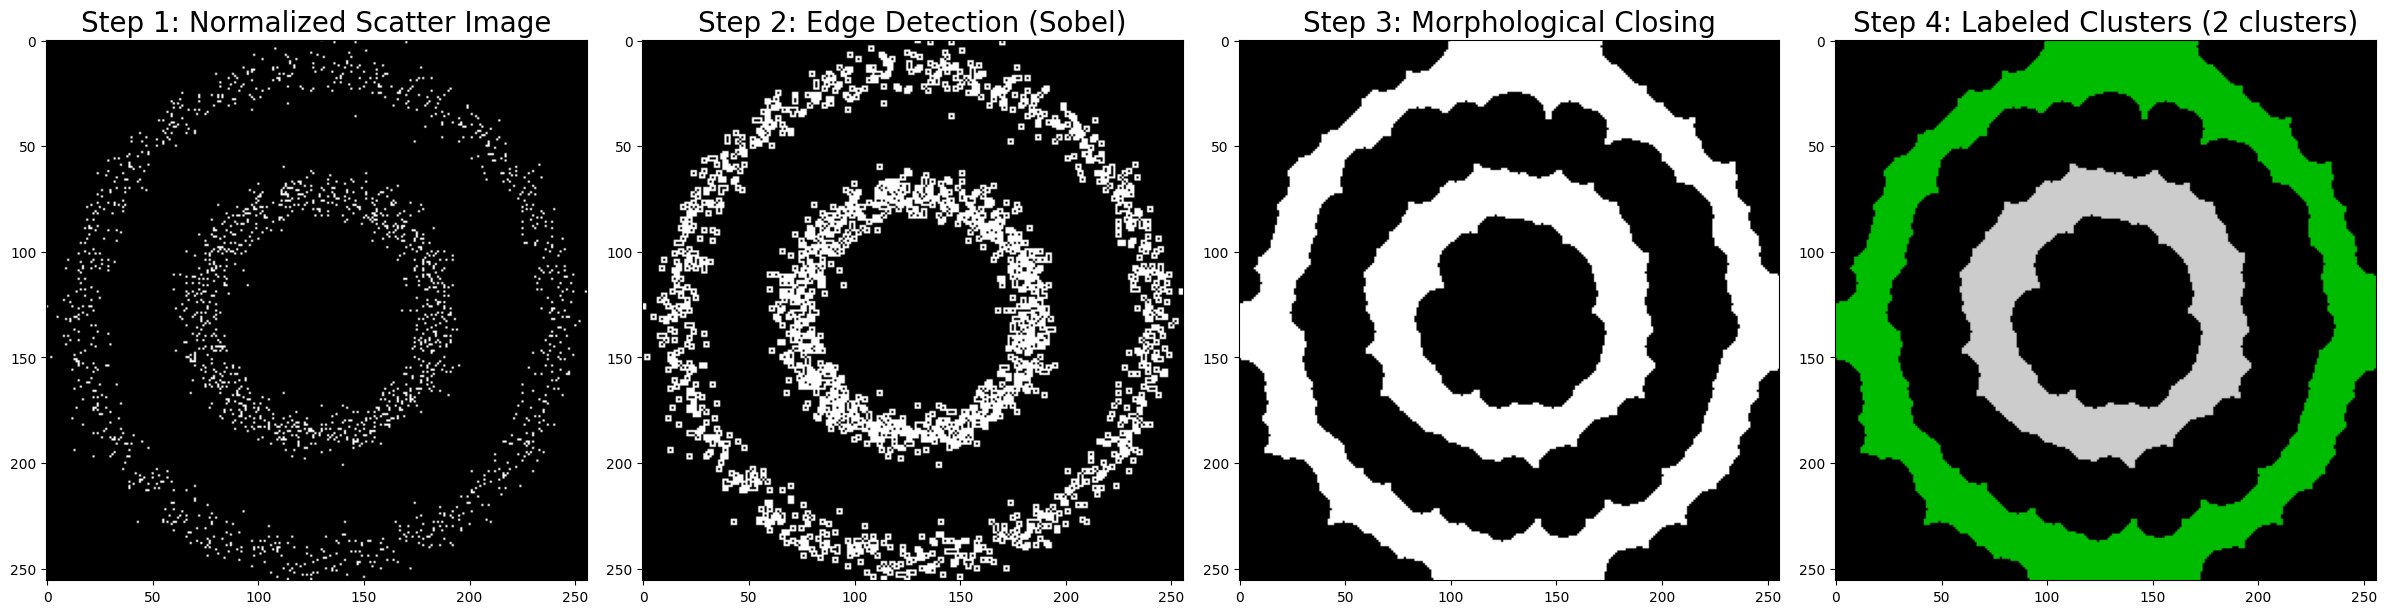

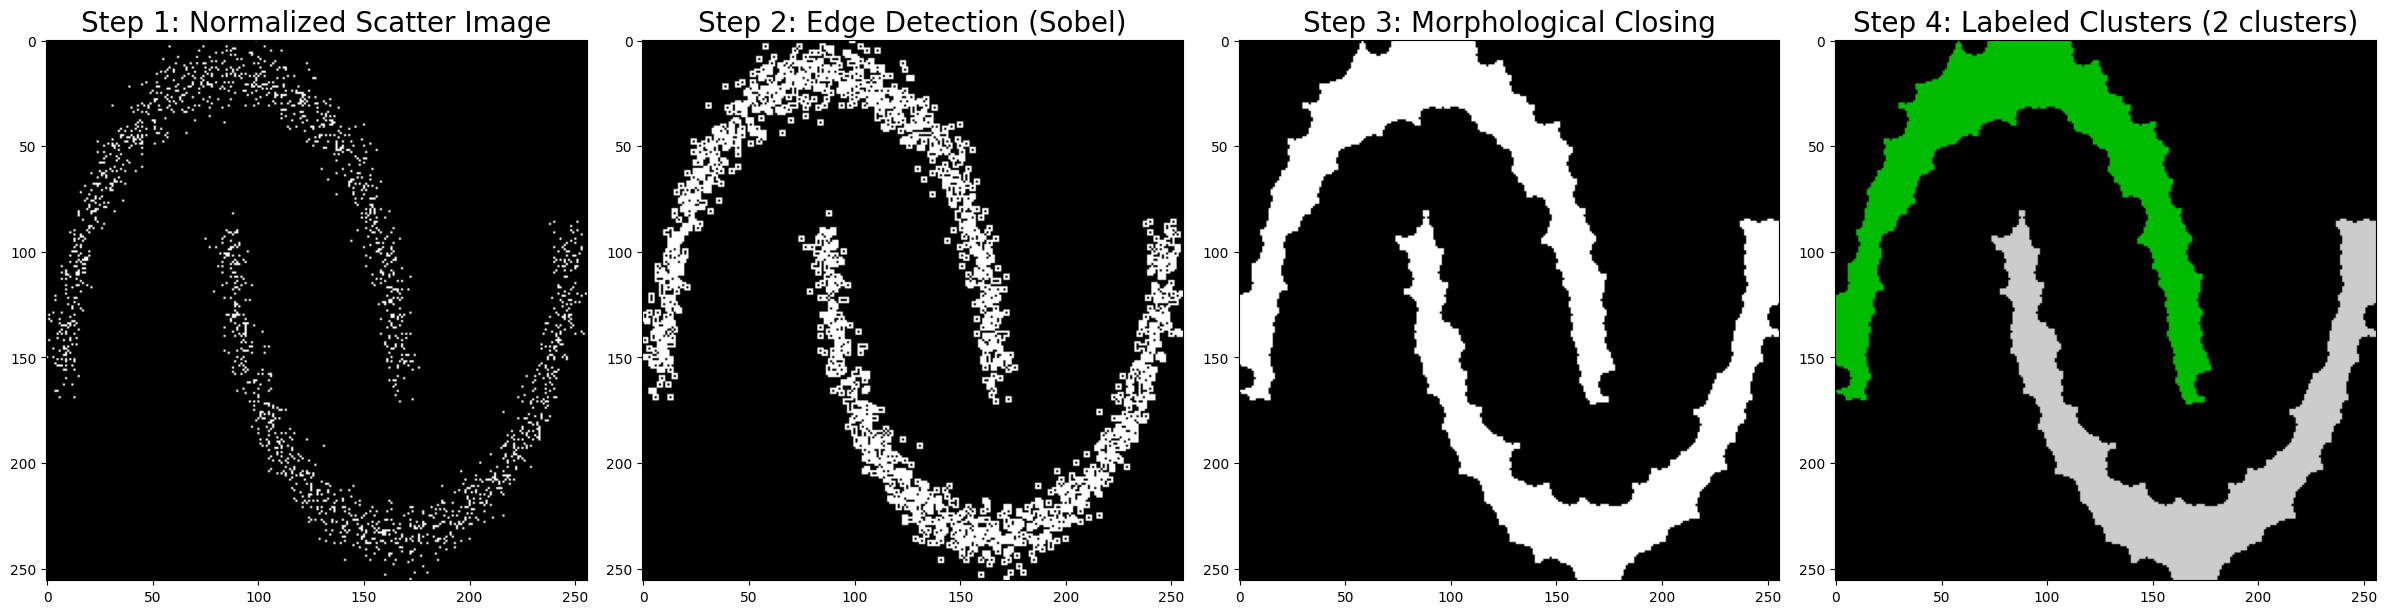

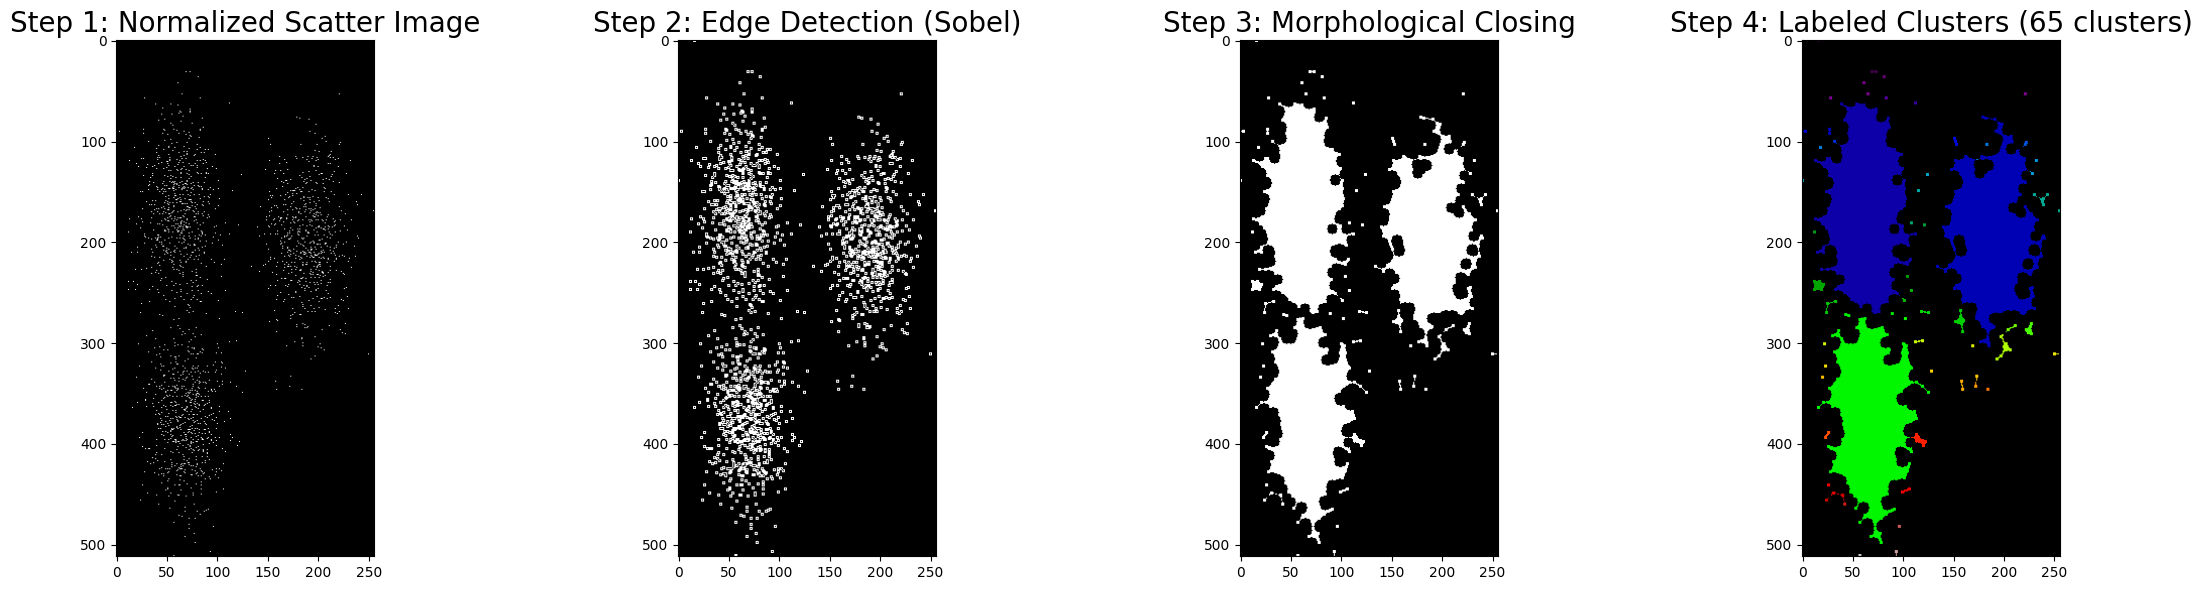

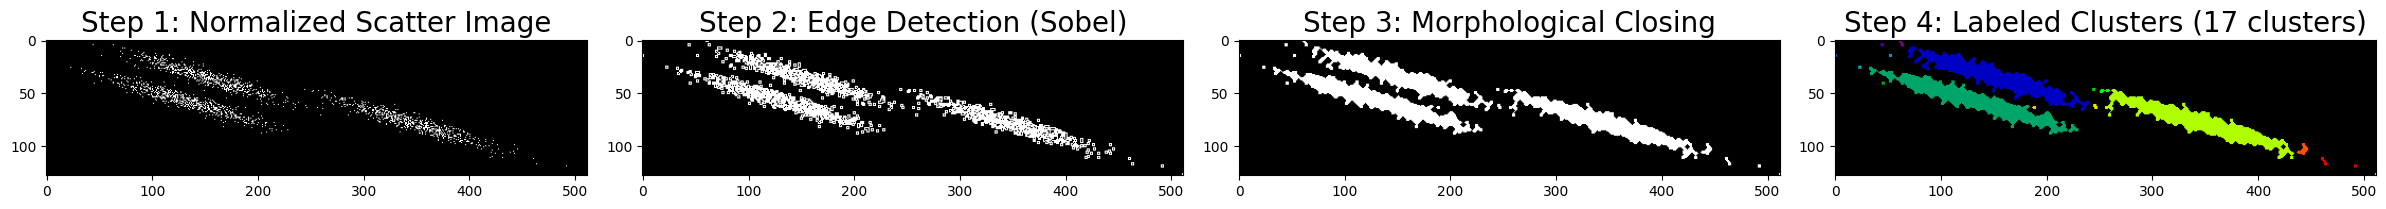

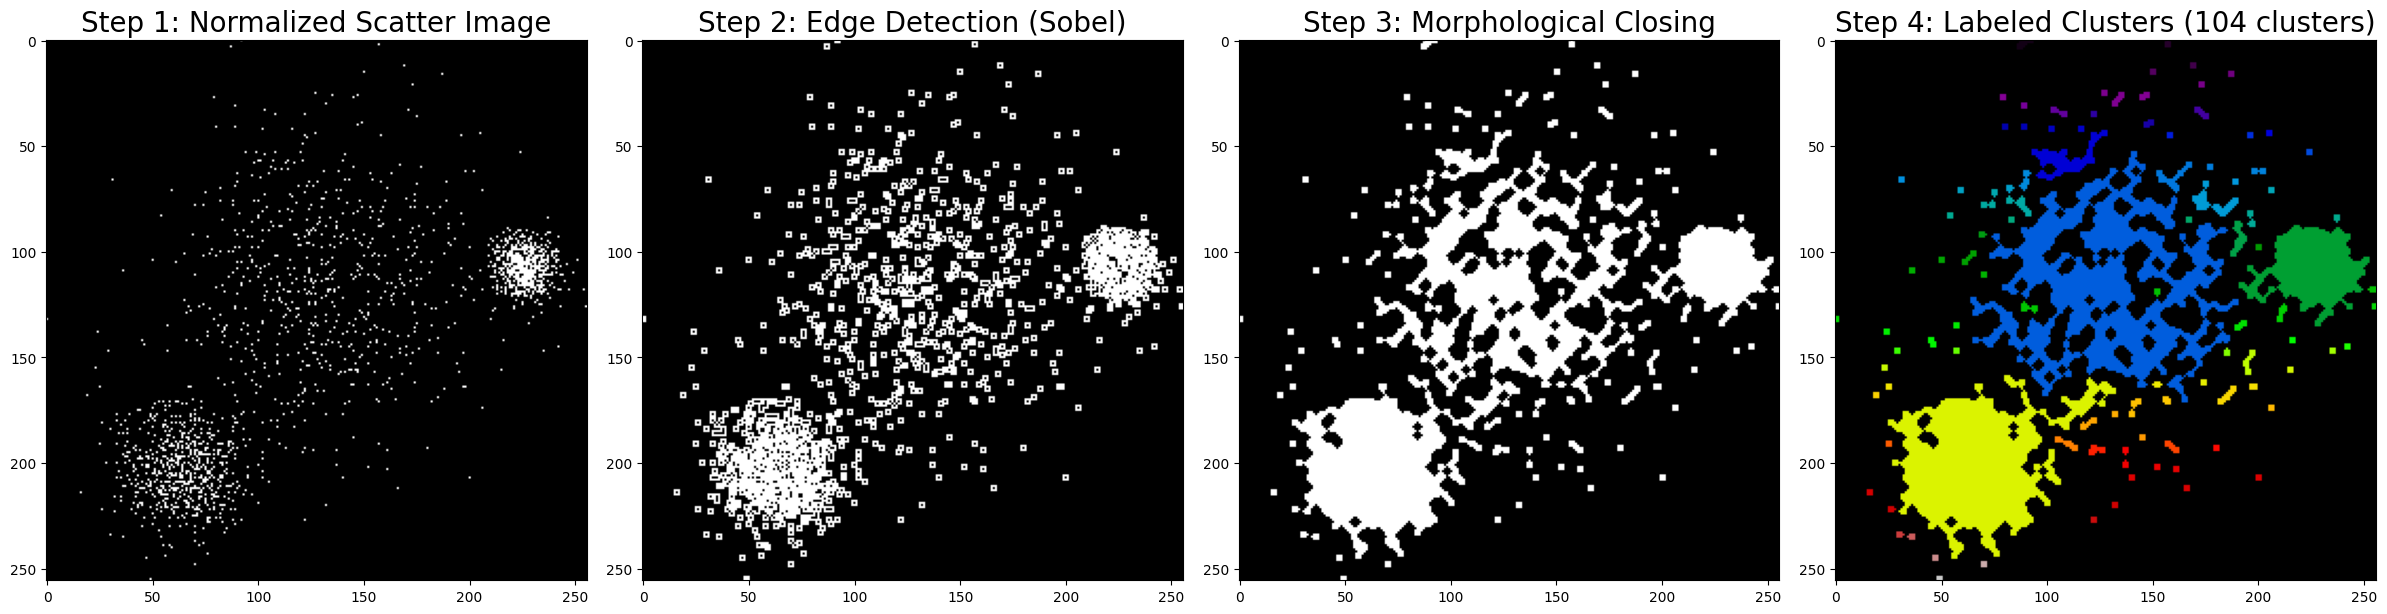

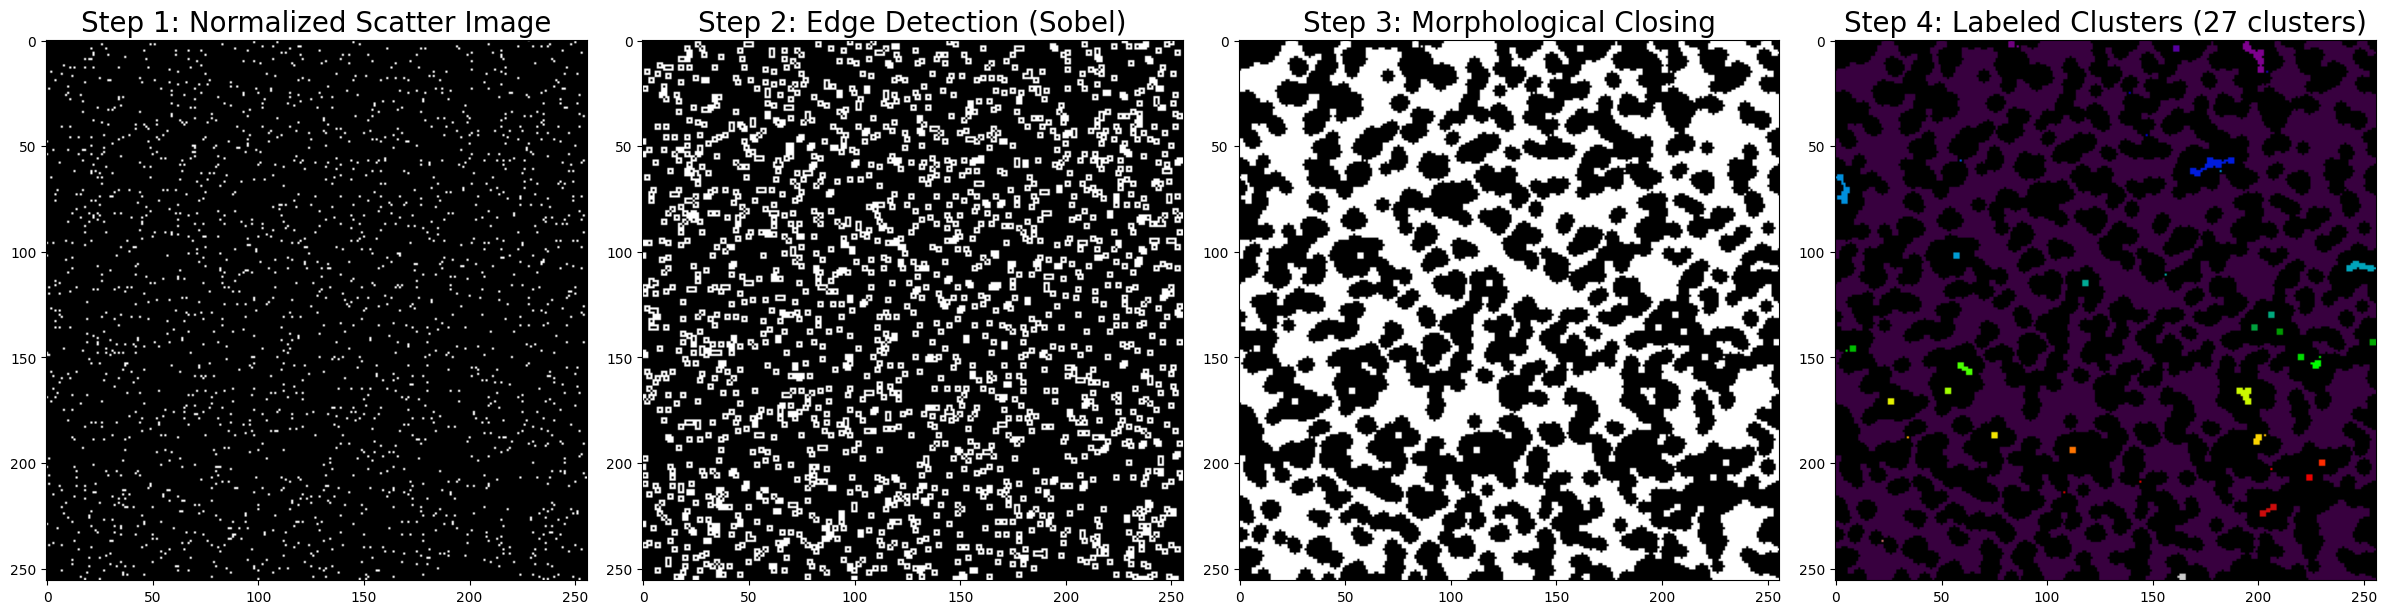

In [5]:
dataset_list = [
    (noisy_circles[0], (256, 256), 9),
    (noisy_moons[0], (256, 256), 5),
    (blobs[0], (512, 256), 5),
    (aniso[0], (128, 512), 2),
    (varied[0], (256, 256), 2),
    (no_structure[0], (256, 256), 3)
]

fontsize = 20

final_clusters = []         # To store labeled cluster images (if needed)
num_clusters_list = []      # To store the number of clusters
point_labels_list = []      # To store point labels for scatter plots

# Loop through the datasets and process each one
for data, img_size, rad in dataset_list:
    scatter_image, edges, closed_edges, labeled_clusters, point_labels = clustering_with_image_segmentation(data, image_size=img_size, radius=rad)

    # Collect the necessary data
    final_clusters.append(labeled_clusters)
    point_labels_list.append(point_labels)
    num_clusters_list.append(len(np.unique(point_labels)))

    # Create a figure with 4 subplots for each step of the process
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    # Step 1: Display the scatter image
    axes[0].imshow(scatter_image, cmap='gray')
    axes[0].set_title("Step 1: Normalized Scatter Image",  fontsize=fontsize)
    # axes[0].axis('off')

    # Step 2: Display the edges detected
    axes[1].imshow(edges, cmap='gray')
    axes[1].set_title("Step 2: Edge Detection (Sobel)", fontsize=fontsize)
    # axes[1].axis('off')

    # Step 3: Display the closed edges after morphological operations
    axes[2].imshow(closed_edges, cmap='gray')
    axes[2].set_title("Step 3: Morphological Closing",  fontsize=fontsize)
    # axes[2].axis('off')

    # Step 4: Display the labeled clusters with the number of unique labels
    num_clusters = len(np.unique(point_labels))  # Calculate the number of unique clusters
    axes[3].imshow(labeled_clusters, cmap='nipy_spectral')
    axes[3].set_title(f"Step 4: Labeled Clusters ({num_clusters} clusters)",  fontsize=fontsize)
    # axes[3].axis('off')

    # Adjust layout and show the plot
    fig.tight_layout()
    plt.show()


### **3.3 Results**

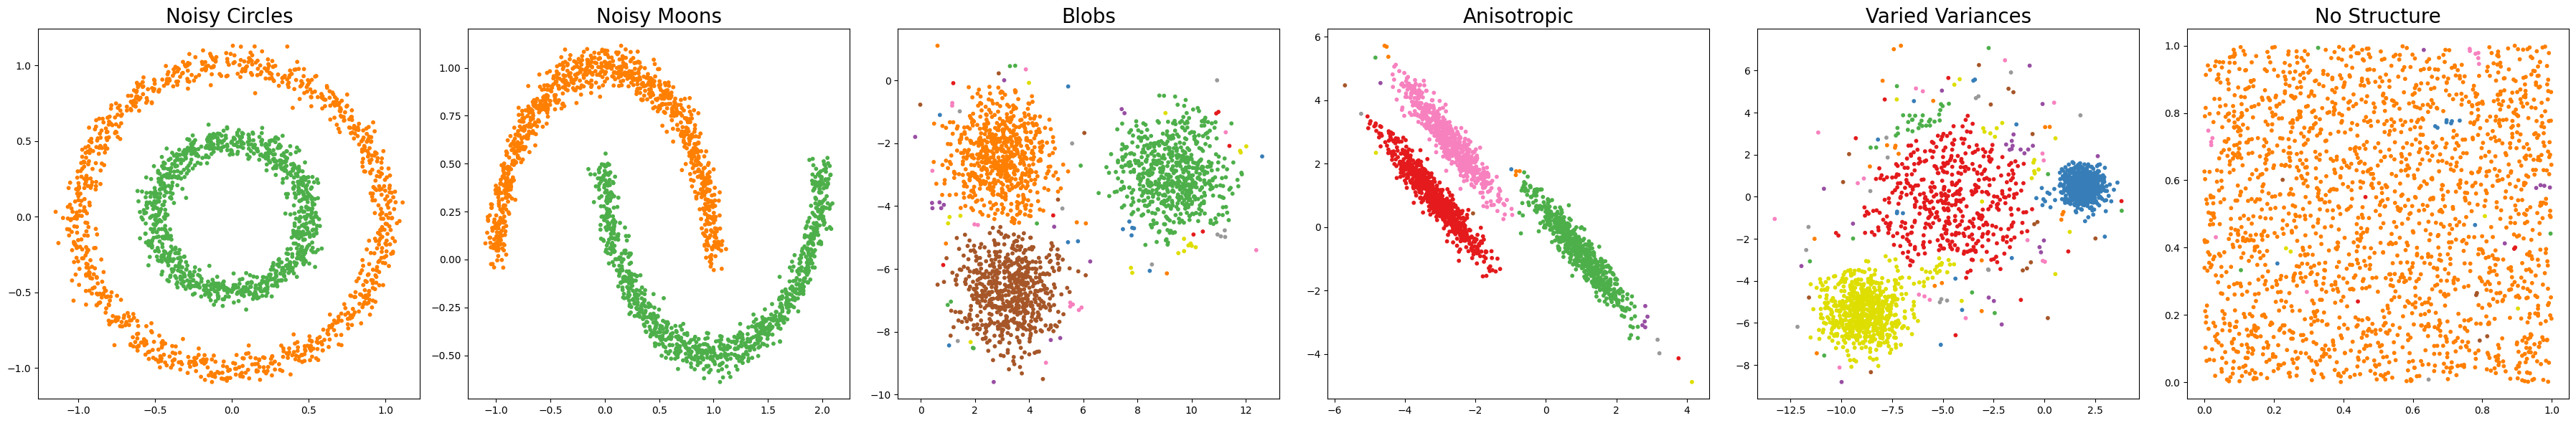

In [8]:
# Define the custom colormap
def get_custom_colors(num_clusters):
    colors = np.array(
        list(islice(cycle([
            "#377eb8", "#ff7f00", "#4daf4a", "#f781bf",
            "#a65628", "#984ea3", "#999999", "#e41a1c", "#dede00"
        ]), num_clusters))
    )
    colors = np.append(colors, ["#000000"])  # For any potential noise/outliers
    return colors

# Create a 1-by-6 subplot for the final labeled clusters
fig, axes = plt.subplots(1, 6, figsize=(36, 6))

for i, (ax, data, point_labels) in enumerate(zip(axes, [d[0] for d in dataset_list], point_labels_list)):
    # Get custom colors for the current dataset
    colors = get_custom_colors(int(max(point_labels) + 1))

    # Scatter plot of the data points, colored by their cluster labels
    ax.scatter(data[:, 0], data[:, 1], s=10, color=colors[point_labels])
    # ax.set_title(f'Dataset {i+1} ({num_clusters_list[i]} clusters)', fontsize=fontsize)
    ax.set_title(titles[i], fontsize=fontsize)
    # ax.axis('off')  # Optional: turn off axes for a cleaner look

# Adjust layout and show the final plot
fig.tight_layout()
plt.show()

## **4. Comparison with Different Clustering Algorithm**

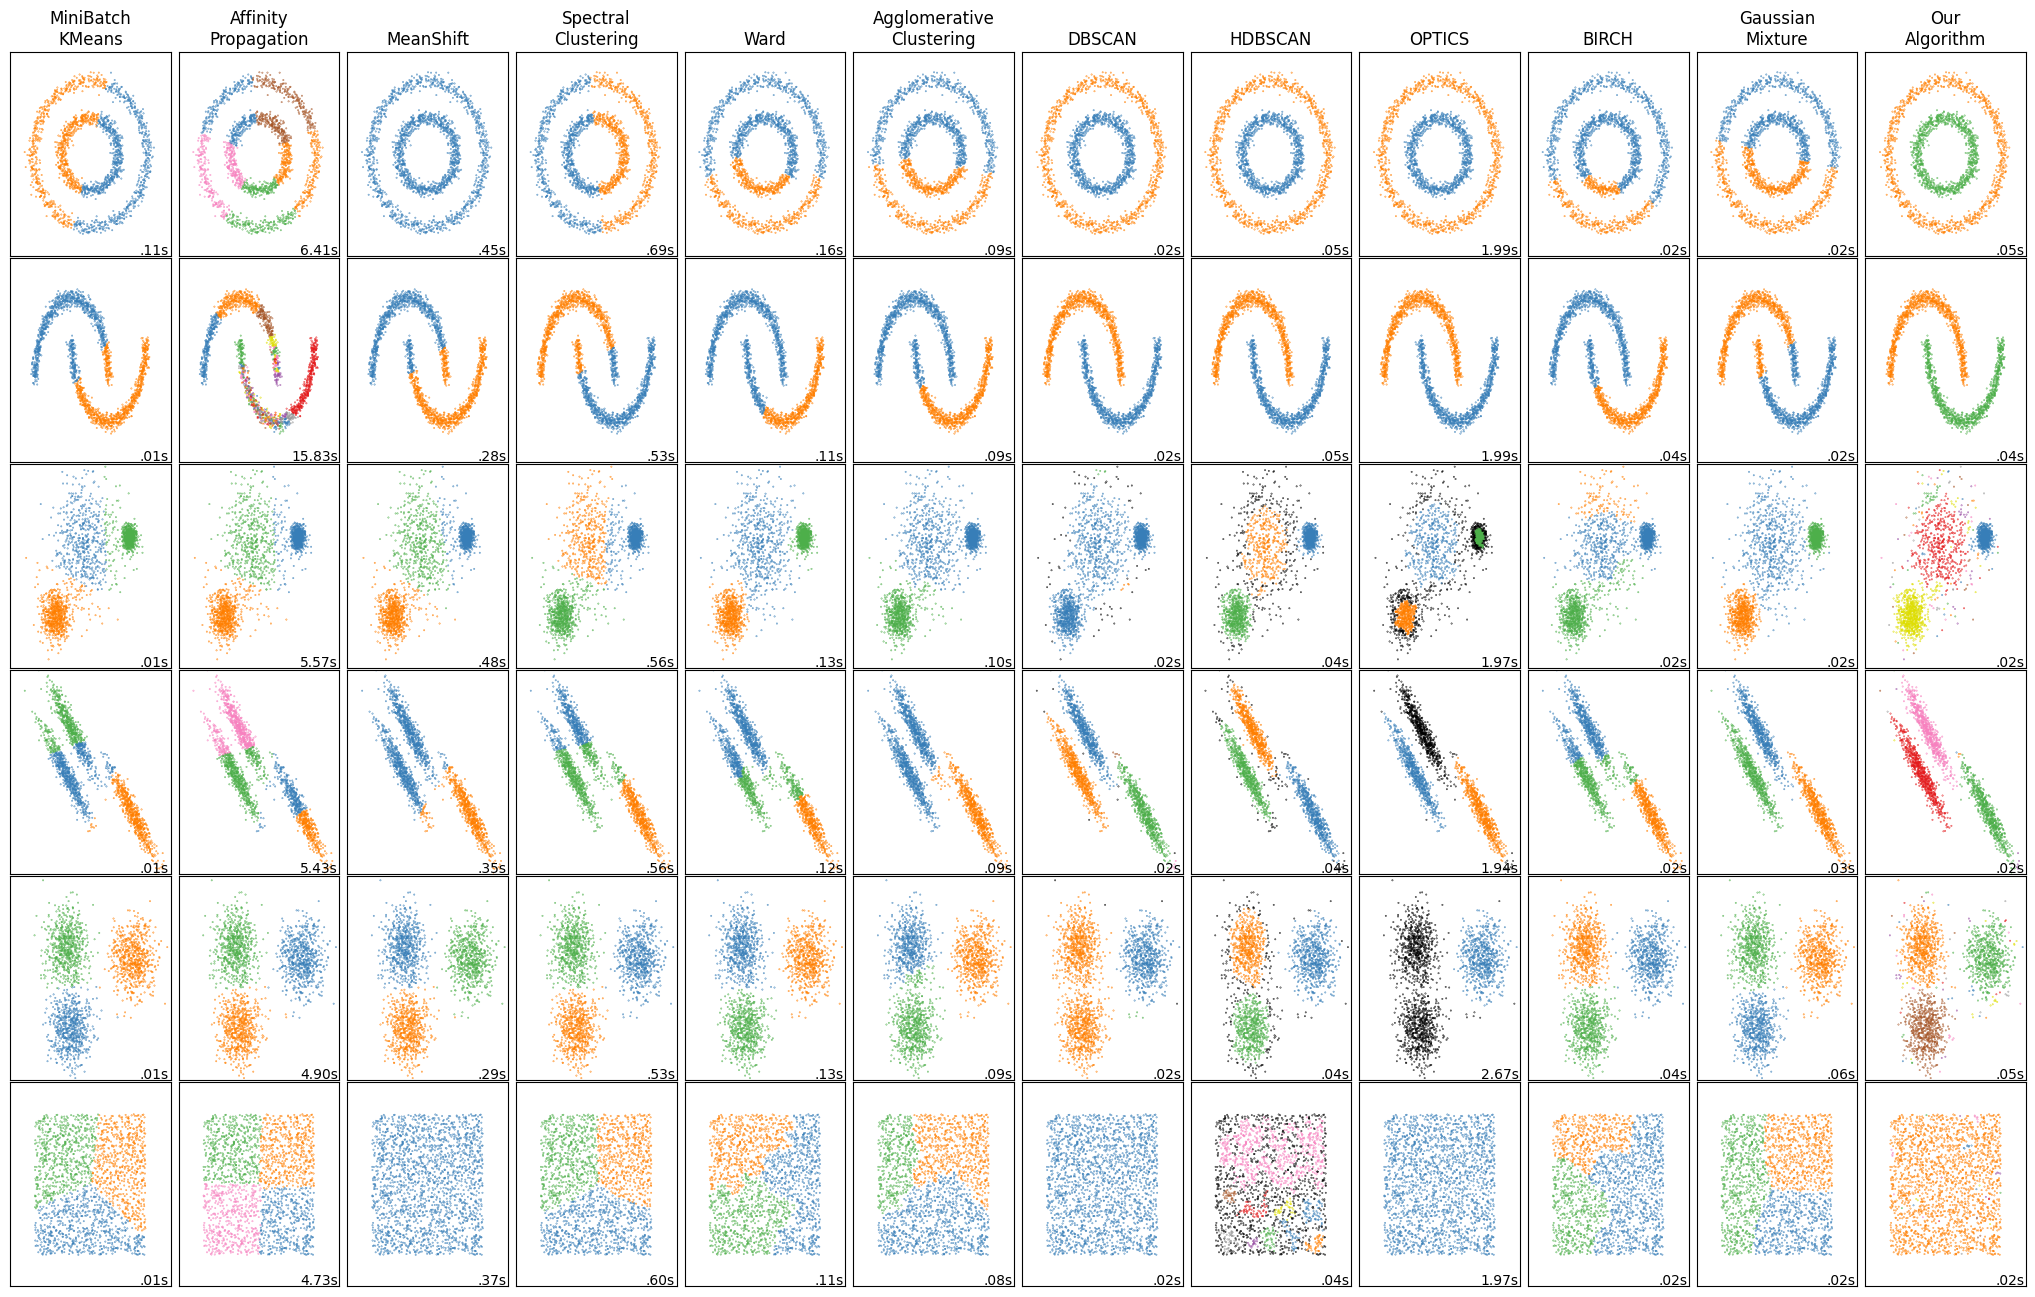

In [9]:
# ============
# Set up cluster parameters
# ============
plt.figure(figsize=(9 * 2 + 3, 13))
plt.subplots_adjust(
    left=0.02, right=0.98, bottom=0.001, top=0.95, wspace=0.05, hspace=0.01
)

plot_num = 1

default_base = {
    "quantile": 0.3,
    "eps": 0.3,
    "damping": 0.9,
    "preference": -200,
    "n_neighbors": 3,
    "n_clusters": 3,
    "min_samples": 7,
    "xi": 0.05,
    "min_cluster_size": 0.1,
    "allow_single_cluster": True,
    "hdbscan_min_cluster_size": 15,
    "hdbscan_min_samples": 3,
    "random_state": 42,
}

datasets = [
    (
        noisy_circles,
        {
            "damping": 0.77,
            "preference": -240,
            "quantile": 0.2,
            "n_clusters": 2,
            "min_samples": 7,
            "xi": 0.08,
        },
    ),
    (
        noisy_moons,
        {
            "damping": 0.75,
            "preference": -220,
            "n_clusters": 2,
            "min_samples": 7,
            "xi": 0.1,
        },
    ),
    (
        varied,
        {
            "eps": 0.18,
            "n_neighbors": 2,
            "min_samples": 7,
            "xi": 0.01,
            "min_cluster_size": 0.2,
        },
    ),
    (
        aniso,
        {
            "eps": 0.15,
            "n_neighbors": 2,
            "min_samples": 7,
            "xi": 0.1,
            "min_cluster_size": 0.2,
        },
    ),
    (blobs, {"min_samples": 7, "xi": 0.1, "min_cluster_size": 0.2}),
    (no_structure, {}),
]


# Mapping dataset indices to their corresponding names
dataset_names = ["noisy_circles", "noisy_moons", "varied", "aniso", "blobs", "no_structure"]

# Define hyperparameters for each dataset
custom_params = {
    "noisy_circles": {"image_size": (256, 256), "radius": 9},
    "noisy_moons": {"image_size": (256, 256), "radius": 5},
    "blobs": {"image_size": (512, 256), "radius": 5},
    "aniso": {"image_size": (128, 512), "radius": 2},
    "varied": {"image_size": (256, 256), "radius": 2},
    "varied": {"image_size": (256, 256), "radius": 2},
    "no_structure": {"image_size": (256, 256), "radius": 3},
}

# ============
# Main plotting loop
# ============
for i_dataset, (dataset, algo_params) in enumerate(datasets):
    params = default_base.copy()
    params.update(algo_params)

    X, y = dataset
    X = StandardScaler().fit_transform(X)

    clustering_algorithms = [
        ("MiniBatch\nKMeans", cluster.MiniBatchKMeans(n_clusters=params["n_clusters"], random_state=params["random_state"])),
        ("Affinity\nPropagation", cluster.AffinityPropagation(damping=params["damping"], preference=params["preference"], random_state=params["random_state"])),
        ("MeanShift", cluster.MeanShift(bin_seeding=True)),
        ("Spectral\nClustering", cluster.SpectralClustering(n_clusters=params["n_clusters"], random_state=params["random_state"])),
        ("Ward", cluster.AgglomerativeClustering(n_clusters=params["n_clusters"], linkage="ward")),
        ("Agglomerative\nClustering", cluster.AgglomerativeClustering(linkage="average", n_clusters=params["n_clusters"])),
        ("DBSCAN", cluster.DBSCAN(eps=params["eps"])),
        ("HDBSCAN", cluster.HDBSCAN(min_cluster_size=params["hdbscan_min_cluster_size"])),
        ("OPTICS", cluster.OPTICS(min_samples=params["min_samples"], xi=params["xi"], min_cluster_size=params["min_cluster_size"])),
        ("BIRCH", cluster.Birch(n_clusters=params["n_clusters"])),
        ("Gaussian\nMixture", mixture.GaussianMixture(n_components=params["n_clusters"], random_state=params["random_state"])),
        ("Our\nAlgorithm", None),  # Placeholder for custom clustering
    ]

    for name, algorithm in clustering_algorithms:
        t0 = time.time()

        if name == "Our\nAlgorithm":
            # Get dataset name using index
            dataset_name = dataset_names[i_dataset]
            image_size = custom_params[dataset_name]["image_size"]
            radius = custom_params[dataset_name]["radius"]

            # Apply custom clustering with specific hyperparameters
            _, _, _, _, point_labels = clustering_with_image_segmentation(X, image_size=image_size, radius=radius)
            y_pred = point_labels  # Use your custom labels
        else:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                algorithm.fit(X)
            y_pred = algorithm.labels_ if hasattr(algorithm, "labels_") else algorithm.predict(X)

        t1 = time.time()

        plt.subplot(len(datasets), len(clustering_algorithms), plot_num)
        if i_dataset == 0:
            plt.title(name, size=12)

        colors = np.array(
            list(islice(cycle(["#377eb8", "#ff7f00", "#4daf4a", "#f781bf", "#a65628", "#984ea3", "#999999", "#e41a1c", "#dede00"]),
                        int(max(y_pred) + 1)))
        )
        colors = np.append(colors, ["#000000"])
        plt.scatter(X[:, 0], X[:, 1], s=0.1, color=colors[y_pred])

        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xticks(())
        plt.yticks(())
        plt.text(0.99, 0.01, ("%.2fs" % (t1 - t0)).lstrip("0"),
                 transform=plt.gca().transAxes, size=10,
                 horizontalalignment="right")
        plot_num += 1

plt.show()